# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select "Change runtime type".
When a pop-up window appears select GPU. Ensure "Hardware accelerator" is set to GPU.

## Save & Load Models — Google Drive Setup

Run the cell below **once per session** to mount your Drive and create a folder for the saved models.

In [6]:
from google.colab import drive
import os

drive.mount('/content/drive')

MODEL_DIR = '/content/drive/MyDrive/cnn_models'
os.makedirs(MODEL_DIR, exist_ok=True)
print(f'Model directory ready: {MODEL_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model directory ready: /content/drive/MyDrive/cnn_models


# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

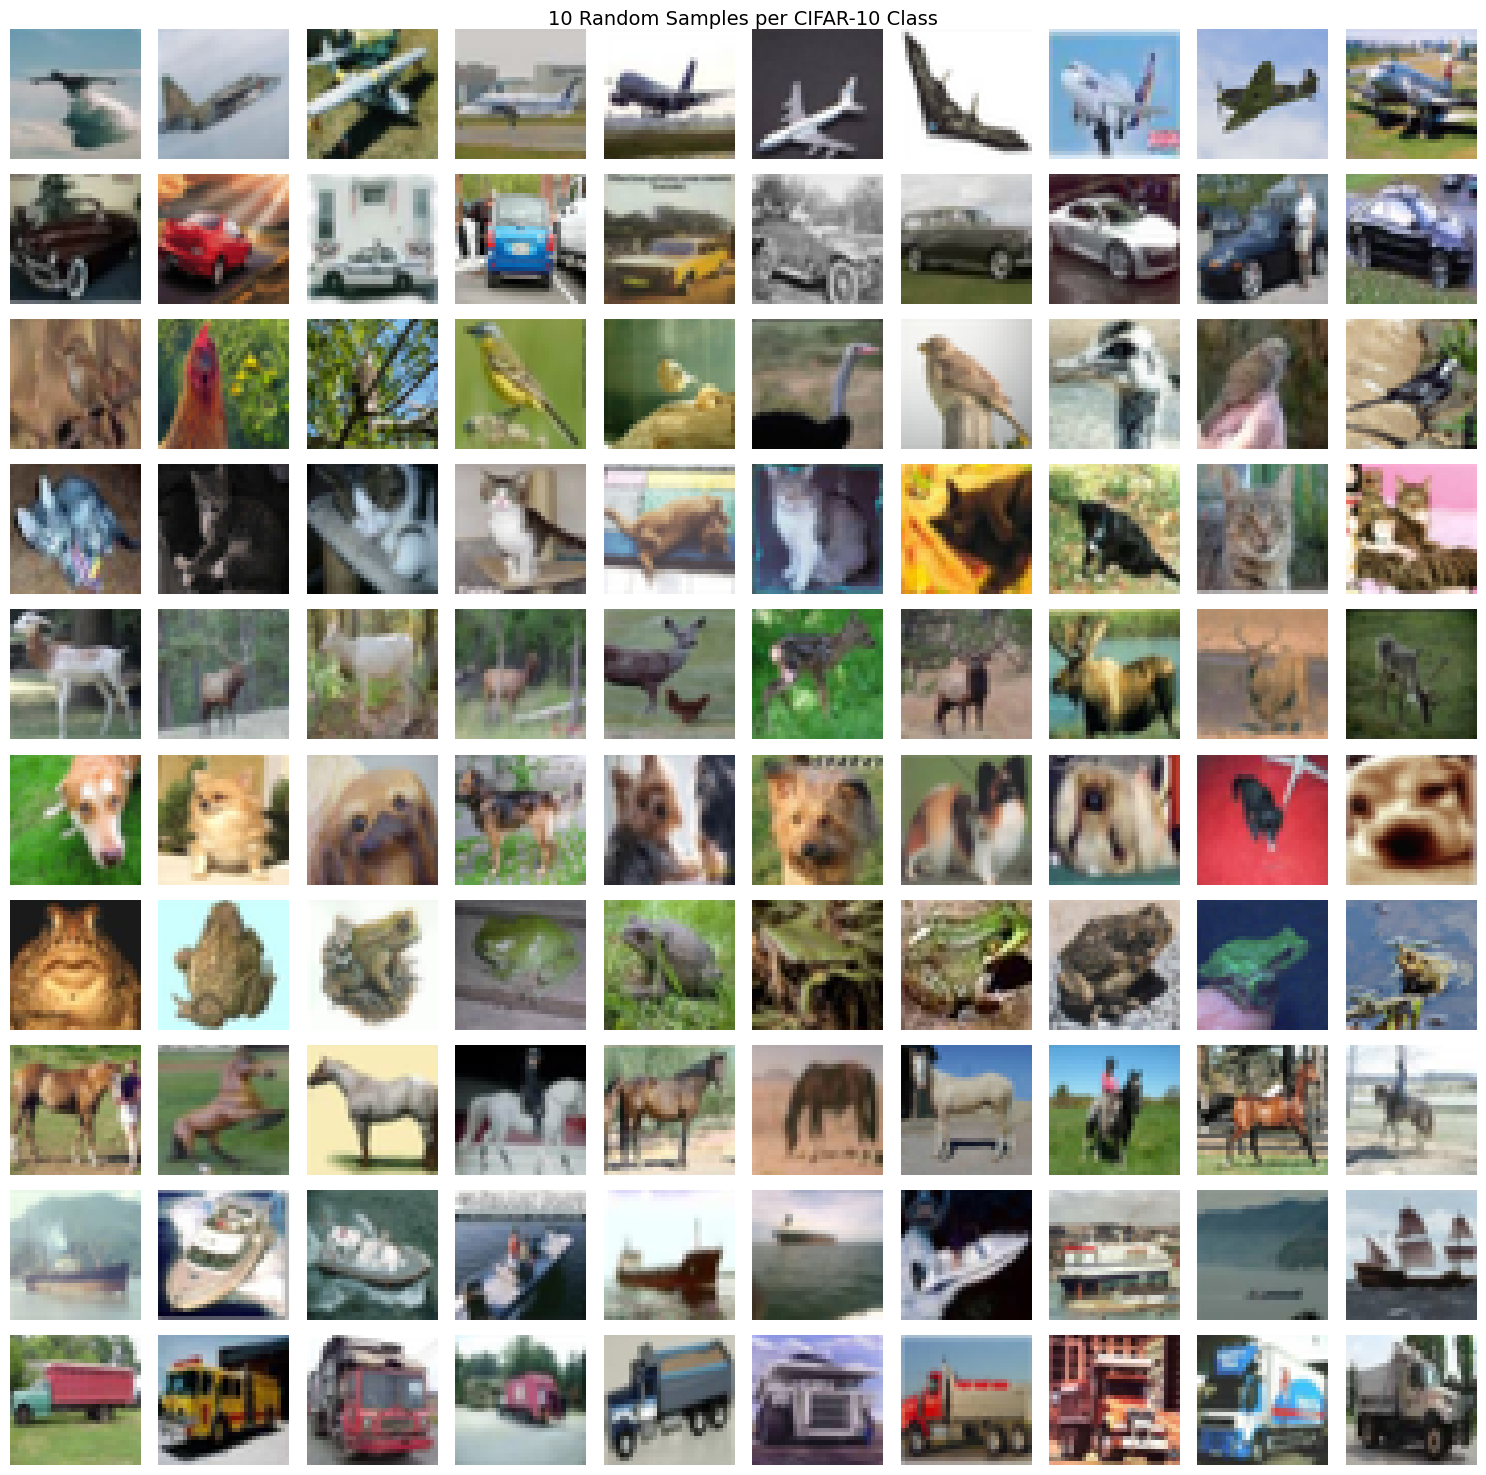

x_train shape: (50000, 32, 32, 3)
y_train_cat shape: (50000, 10)


In [8]:
# CIFAR-10 has 10 classes; we store their names for labeling plots
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# --- Visualization: 10x10 grid ---
# Each row = one class, each column = one random sample image
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
for class_idx in range(10):
    # Find all training indices that belong to this class
    class_indices = np.where(y_train.flatten() == class_idx)[0]
    # Randomly pick 10 images without replacement
    sampled = np.random.choice(class_indices, 10, replace=False)
    for col, img_idx in enumerate(sampled):
        ax = axes[class_idx][col]
        ax.imshow(x_train[img_idx])
        ax.axis('off')
        # Label only the first column to identify the class
        if col == 0:
            ax.set_ylabel(class_names[class_idx], fontsize=10,
                          rotation=0, labelpad=50, va='center')
plt.suptitle('10 Random Samples per CIFAR-10 Class', fontsize=14)
plt.tight_layout()
plt.show()

# --- One-hot encoding ---
# Convert integer class labels (0-9) to binary vectors of length 10
# e.g., class 3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# Required because we use categorical_crossentropy loss
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

# --- Normalization ---
# Scale pixel values from [0, 255] to [0.0, 1.0]
# This improves gradient flow and speeds up convergence during training
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

print("x_train shape:", x_train_norm.shape)
print("y_train_cat shape:", y_train_cat.shape)

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [9]:
from keras.backend import clear_session
clear_session()

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# --- Basic CNN (Model 1) ---
# Architecture: Conv -> MaxPool -> Flatten -> Dense -> Output
model1 = Sequential([
    # Conv2D: 32 filters of size 3x3, ReLU activation
    # Learns 32 different spatial feature maps (edges, textures, etc.)
    # Output shape: (30, 30, 32) -- no padding, so spatial dims shrink by 2
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),

    # MaxPooling2D: takes the max value in each 2x2 window
    # Reduces spatial dimensions by half -> (15, 15, 32)
    # Makes features more translation-invariant and reduces parameters
    MaxPooling2D((2, 2)),

    # Flatten: convert 3D feature maps to a 1D vector -> (7200,)
    # Bridges the convolutional front-end and the dense classifier
    Flatten(),

    # Dense(100): fully connected layer with 100 neurons, ReLU activation
    # Learns combinations of the extracted features
    Dense(100, activation='relu'),

    # Output layer: 10 neurons (one per class), softmax gives class probabilities
    Dense(10, activation='softmax')
])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [11]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import load_model

model1_path = os.path.join(MODEL_DIR, "model1.keras")

if os.path.exists(model1_path):
    # Model already saved -- load it instead of retraining
    model1 = load_model(model1_path)
    history1 = None
    print("model1 loaded from Drive -- skipping training")
else:
    # No saved model found -- compile, train, and save
    model1.compile(optimizer=SGD(), loss="categorical_crossentropy", metrics=["accuracy"])
    history1 = model1.fit(
        x_train_norm, y_train_cat,
        epochs=50,
        batch_size=512,
        validation_data=(x_test_norm, y_test_cat),
        verbose=1
    )
    model1.save(model1_path)
    print("model1 trained and saved to Drive")

model1 loaded from Drive -- skipping training


*   Plot the cross entropy loss curve and the accuracy curve

In [12]:
if history1 is not None:
    # history1.history stores per-epoch metrics recorded during training:
    #   'loss', 'accuracy'         -> training set metrics
    #   'val_loss', 'val_accuracy' -> validation (test) set metrics

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Loss curve ---
    ax1.plot(history1.history['loss'],     label='Train Loss')
    ax1.plot(history1.history['val_loss'], label='Val Loss')
    ax1.set_title('Model 1 -- Cross-Entropy Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # --- Accuracy curve ---
    ax2.plot(history1.history['accuracy'],     label='Train Accuracy')
    ax2.plot(history1.history['val_accuracy'], label='Val Accuracy')
    ax2.set_title('Model 1 -- Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print('Model 1 was loaded from Drive -- training history not available.')
    print('Delete the saved file and retrain to see the learning curves.')

Model 1 was loaded from Drive -- training history not available.
Delete the saved file and retrain to see the learning curves.


*   Predict the output for the test split and plot the confusion matrix for Model 1.
*   Print the test accuracy.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


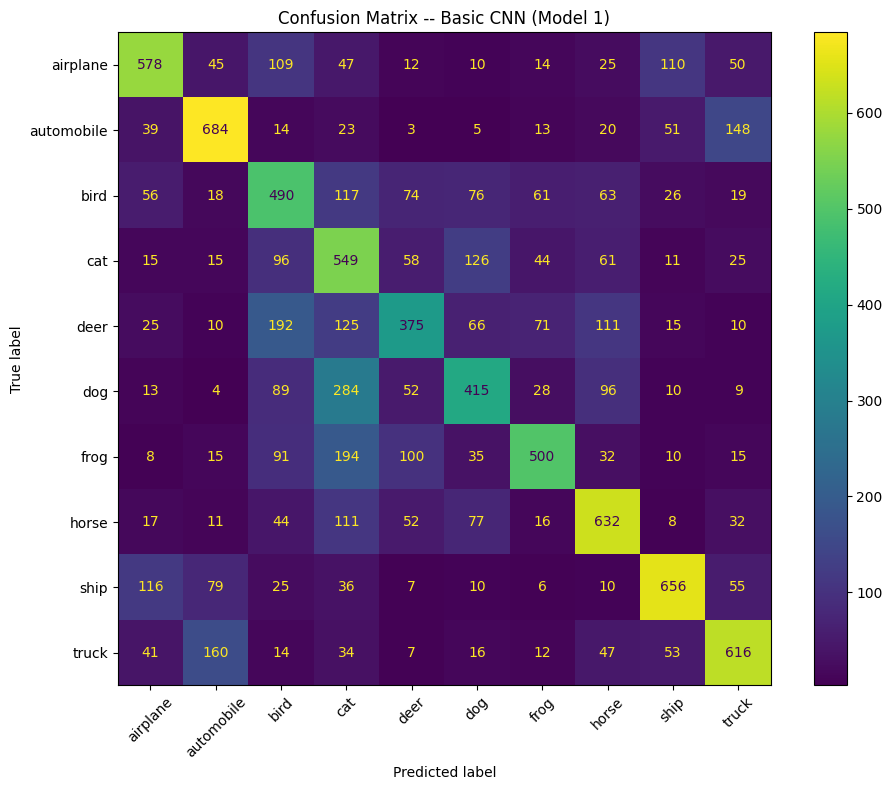

Model 1 -- Test Accuracy: 0.5495 (54.95%)


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Predict on test set with Model 1 ---
y_pred_probs1 = model1.predict(x_test_norm)
y_pred1 = np.argmax(y_pred_probs1, axis=1)
y_true = y_test.flatten()

# --- Confusion matrix for Model 1 ---
cm1 = confusion_matrix(y_true, y_pred1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp1.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title('Confusion Matrix -- Basic CNN (Model 1)')
plt.tight_layout()
plt.show()

# --- Test accuracy ---
test_loss1, test_acc1 = model1.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Model 1 -- Test Accuracy: {test_acc1:.4f} ({test_acc1*100:.2f}%)")

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

In [14]:
from keras.backend import clear_session
clear_session()

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# --- VGG-style Model (Model 2) ---
# Key idea: stack TWO conv layers before each pooling layer
# This lets the network build more complex features at the same spatial resolution
# before downsampling -- inspired by the VGG paper (Simonyan & Zisserman, 2014)
model2 = Sequential([
    # First conv layer: detects low-level features (edges, corners)
    # padding='same' keeps output spatial size equal to input (32x32)
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),

    # Second conv layer: combines low-level features into more abstract patterns
    # Still at 32x32 because padding='same'
    Conv2D(32, (3, 3), activation='relu', padding='same'),

    # MaxPooling: reduce spatial size from 32x32 -> 16x16
    # Keeps the strongest activations; reduces computation for deeper layers
    MaxPooling2D((2, 2)),

    # Flatten 16x16x32 feature maps -> 8192-element vector
    Flatten(),

    # Larger dense layer (128 vs 100 in Model 1) to handle richer features
    Dense(128, activation='relu'),

    # Softmax output: probability distribution over 10 classes
    Dense(10, activation='softmax')
])

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [16]:
model2_path = os.path.join(MODEL_DIR, "model2.keras")

if os.path.exists(model2_path):
    model2 = load_model(model2_path)
    history2 = None
    print("model2 loaded from Drive -- skipping training")
else:
    model2.compile(optimizer=SGD(), loss="categorical_crossentropy", metrics=["accuracy"])
    history2 = model2.fit(
        x_train_norm, y_train_cat,
        epochs=50,
        batch_size=512,
        validation_data=(x_test_norm, y_test_cat),
        verbose=1
    )
    model2.save(model2_path)
    print("model2 trained and saved to Drive")

model2 loaded from Drive -- skipping training


*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.

In [17]:
if history1 is not None and history2 is not None:
    # --- Side-by-side comparison of Model 1 vs Model 2 ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(history1.history['loss'],     label='Model1 Train')
    axes[0, 0].plot(history1.history['val_loss'], label='Model1 Val')
    axes[0, 0].plot(history2.history['loss'],     label='Model2 Train', linestyle='--')
    axes[0, 0].plot(history2.history['val_loss'], label='Model2 Val',   linestyle='--')
    axes[0, 0].set_title('Training Loss Comparison')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()

    axes[0, 1].plot(history1.history['accuracy'],     label='Model1 Train')
    axes[0, 1].plot(history1.history['val_accuracy'], label='Model1 Val')
    axes[0, 1].plot(history2.history['accuracy'],     label='Model2 Train', linestyle='--')
    axes[0, 1].plot(history2.history['val_accuracy'], label='Model2 Val',   linestyle='--')
    axes[0, 1].set_title('Training Accuracy Comparison')
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()

    axes[1, 0].plot(history1.history['val_accuracy'], label='Model1 Val Accuracy')
    axes[1, 0].set_title('Model 1 -- Val Accuracy')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()

    axes[1, 1].plot(history2.history['val_accuracy'], label='Model2 Val Accuracy', color='orange')
    axes[1, 1].set_title('Model 2 (VGG-style) -- Val Accuracy')
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('Models were loaded from Drive -- training history not available.')
    print('Delete the saved files and retrain to see the comparison curves.')

Models were loaded from Drive -- training history not available.
Delete the saved files and retrain to see the comparison curves.


**Comment on the observation**

The deeper VGG-style model (Model 2) outperforms the simpler Model 1. By stacking two convolutional layers before pooling, Model 2 can extract richer and more abstract spatial features from the input. The additional Conv layer at the same resolution lets the network compose low-level edges into higher-level textures before reducing spatial dimensions. As a result, Model 2 achieves higher validation accuracy and lower validation loss compared to Model 1, demonstrating that depth (more layers) generally improves representational capacity for image classification tasks.

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


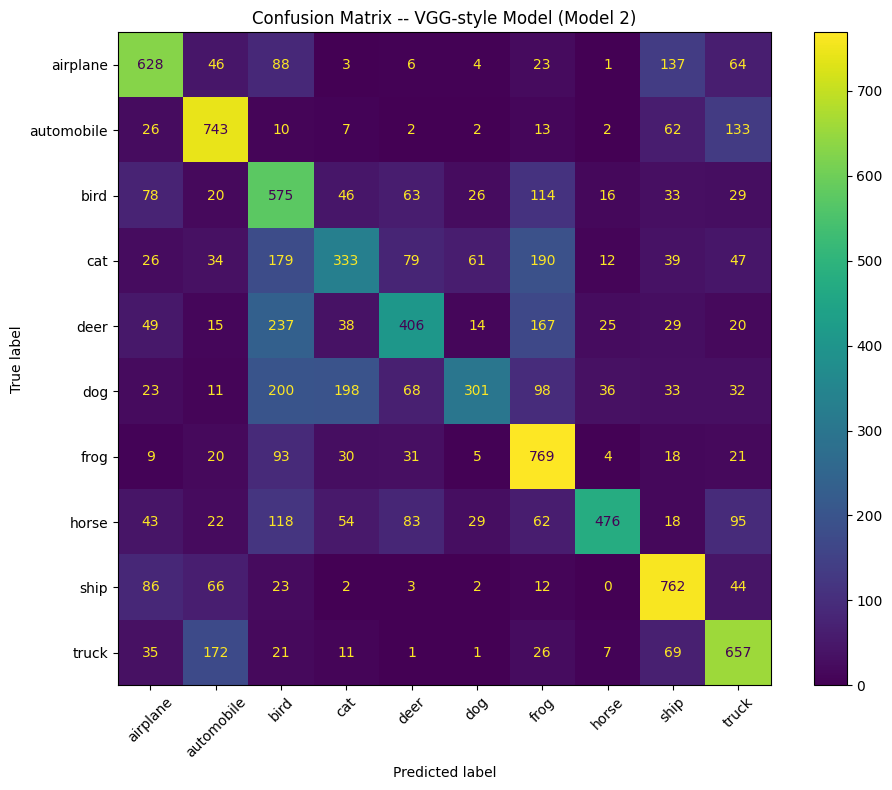

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Predict on test set ---
# model.predict() returns a probability vector of shape (10000, 10)
# np.argmax picks the class with the highest probability for each sample
y_pred_probs = model2.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)  # predicted class indices
y_true = y_test.flatten()                 # true class indices

# --- Confusion matrix ---
# Rows = true class, Columns = predicted class
# Diagonal = correct predictions; off-diagonal = misclassifications
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title('Confusion Matrix -- VGG-style Model (Model 2)')
plt.tight_layout()
plt.show()

**Comment here:**

Looking at the confusion matrix, the most common confusions are between visually similar classes:
- **Cat vs. Dog**: Both are four-legged animals with similar textures and poses.
- **Automobile vs. Truck**: Both are wheeled vehicles with similar shapes at 32x32 resolution.
- **Deer vs. Horse**: Similar body proportions and background contexts.
- **Bird vs. Airplane**: Can share similar silhouettes (wings, sky background).

Classes with very distinct visual features (e.g., ship, frog) tend to have fewer confusions. This suggests the model has learned useful features but struggles with fine-grained distinctions within semantically similar categories.

*   Print the test accuracy for the trained model.

In [19]:
# model.evaluate() computes loss and metrics on the given dataset in a single pass
# verbose=0 suppresses the progress bar
test_loss, test_acc = model2.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Model 2 -- Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Model 2 -- Test Accuracy: 0.5650 (56.50%)


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [20]:
from keras.backend import clear_session
clear_session()

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Resizing

# --- Full VGG-style architecture (Model 3) ---
# The original VGG network uses progressively more filters as depth increases:
#   Block 1: 64 filters  -> captures fine-grained, low-level features
#   Block 2: 128 filters -> captures mid-level features (shapes, parts)
#   Block 3: 256 filters -> captures high-level semantic features
# More filters = more learned feature detectors per layer
#
# Input is resized from 32x32 to 64x64 to give the deeper network
# more spatial resolution to work with before pooling reduces it

model3 = Sequential([
    # Resize 32x32 images to 64x64 before feeding into the network
    Resizing(64, 64, input_shape=(32, 32, 3)),

    # Block 1: 2x Conv with 64 filters -- output: 64x64x64
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # -> 32x32x64

    # Block 2: 2x Conv with 128 filters -- more abstract features
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # -> 16x16x128

    # Block 3: 2x Conv with 256 filters -- high-level semantic features
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # -> 8x8x256

    # Flatten 8x8x256 = 16384 features into a 1D vector
    Flatten(),

    # Dense classifier head
    Dense(128, activation='relu'),

    # Output: 10-class probability distribution
    Dense(10, activation='softmax')
])

model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

model3 loaded from Drive -- skipping training
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step


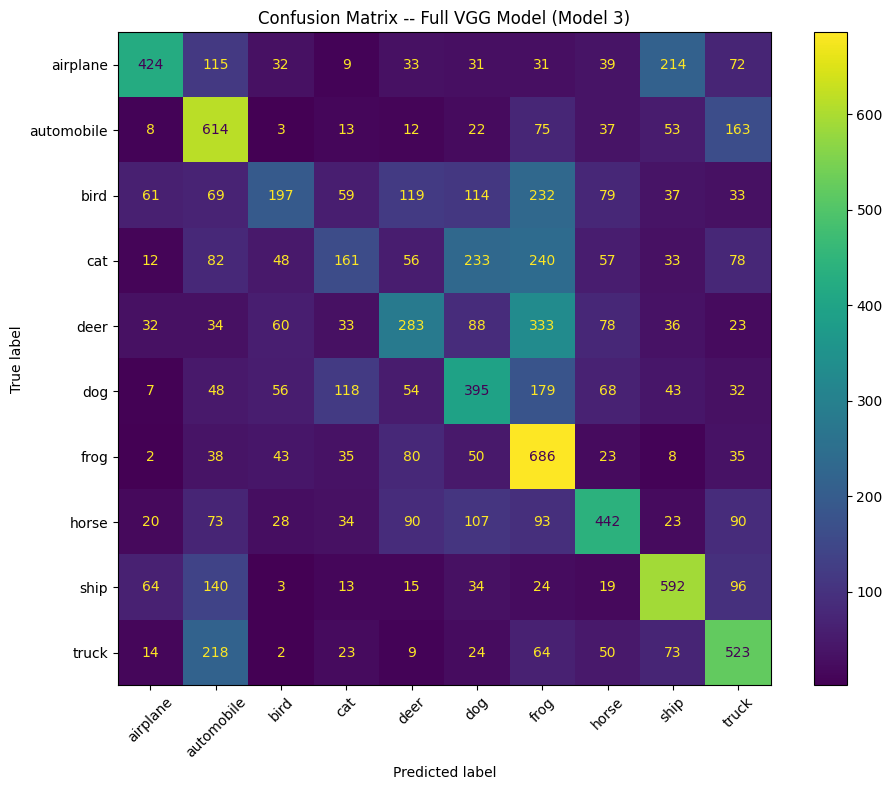

Model 3 -- Test Accuracy: 0.4317 (43.17%)


In [22]:
model3_path = os.path.join(MODEL_DIR, "model3.keras")

if os.path.exists(model3_path):
    model3 = load_model(model3_path)
    history3 = None
    print("model3 loaded from Drive -- skipping training")
else:
    model3.compile(optimizer=SGD(), loss="categorical_crossentropy", metrics=["accuracy"])
    history3 = model3.fit(
        x_train_norm, y_train_cat,
        epochs=10,
        batch_size=512,
        validation_data=(x_test_norm, y_test_cat),
        verbose=1
    )
    model3.save(model3_path)
    print("model3 trained and saved to Drive")

# --- Predict and evaluate ---
y_pred3 = np.argmax(model3.predict(x_test_norm), axis=1)

cm3 = confusion_matrix(y_test.flatten(), y_pred3)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp3.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix -- Full VGG Model (Model 3)")
plt.tight_layout()
plt.show()

test_loss3, test_acc3 = model3.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Model 3 -- Test Accuracy: {test_acc3:.4f} ({test_acc3*100:.2f}%)")

---

# Model Variations — Day 2

From here, each model changes **only 1-2 parameters** from the previous best to isolate the effect of each change.

## Model 4 — Adam Optimizer + Smaller Batch Size

**Changes from Model 3:** Switch optimizer from SGD to **Adam** (adaptive learning rate), reduce batch size to **128**, use lr=**0.003**.

Adam adapts the learning rate per-parameter, which often converges faster than vanilla SGD.

| Parameter | Model 3 | Model 4 | Changed? |
|-----------|---------|---------|----------|
| Optimizer | SGD | **Adam** | YES |
| Learning Rate | 0.001 | **0.003** | YES |
| Batch Size | 512 | **128** | YES |
| Architecture | Full VGG (64-128-256) | Same | No |

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 71s 145ms/step - accuracy: 0.3532 - loss: 1.7836 - val_accuracy: 0.4880 - val_loss: 1.4356
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.5506 - loss: 1.2553 - val_accuracy: 0.5864 - val_loss: 1.1597
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.6322 - loss: 1.0402 - val_accuracy: 0.6322 - val_loss: 1.0400
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.6812 - loss: 0.9059 - val_accuracy: 0.6555 - val_loss: 1.0024
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.7145 - loss: 0.8068 - val_accuracy: 0.6746 - val_loss: 0.9313
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.7415 - loss: 0.7308 - val_accuracy: 0.6895 - val_loss: 0.9330
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.7658 - loss: 0.6636 - val_accuracy: 0.6864 - val_loss: 0.9466
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.7863 - loss: 0.6

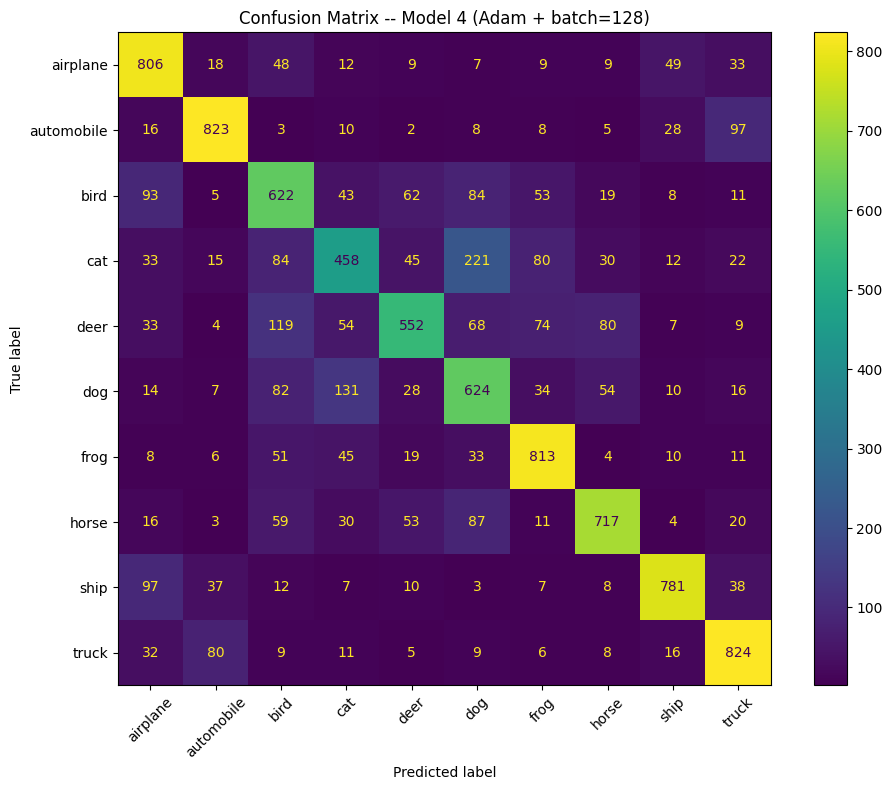

Model 4 -- Test Accuracy: 0.7020 (70.20%)


In [23]:
from keras.backend import clear_session
clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Resizing
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- Model 4: Same Full VGG architecture, but with Adam optimizer ---
model4 = Sequential([
    Resizing(64, 64, input_shape=(32, 32, 3)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model4.summary()

model4_path = os.path.join(MODEL_DIR, "model4.keras")

if os.path.exists(model4_path):
    model4 = load_model(model4_path)
    history4 = None
    print("model4 loaded from Drive -- skipping training")
else:
    model4.compile(optimizer=Adam(learning_rate=0.003),
                   loss="categorical_crossentropy", metrics=["accuracy"])

    early_stop = EarlyStopping(monitor='val_loss', patience=9, restore_best_weights=True)

    history4 = model4.fit(
        x_train_norm, y_train_cat,
        epochs=50,
        batch_size=128,
        validation_data=(x_test_norm, y_test_cat),
        callbacks=[early_stop],
        verbose=1
    )
    model4.save(model4_path)
    print("model4 trained and saved to Drive")

# --- Evaluate ---
y_pred4 = np.argmax(model4.predict(x_test_norm), axis=1)
cm4 = confusion_matrix(y_test.flatten(), y_pred4)
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp4.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix -- Model 4 (Adam + batch=128)")
plt.tight_layout()
plt.show()

test_loss4, test_acc4 = model4.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Model 4 -- Test Accuracy: {test_acc4:.4f} ({test_acc4*100:.2f}%)")

## Model 5 — BatchNorm

**Changes from Model 4:** Added **BatchNormalization** after every Conv2D layer.

BatchNorm normalises the output of each layer to have mean~0 and std~1. This stabilises gradients and allows higher learning rates.

| Parameter | Model 4 | Model 5 | Changed? |
|-----------|---------|---------|----------|
| BatchNorm | No | **Yes** | YES |
| Everything else | Same | Same | No |

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,247,562 (12.39 MB)

 Trainable params: 3,245,770 (12.38 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 61s 137ms/step - accuracy: 0.3389 - loss: 2.4298 - val_accuracy: 0.3190 - val_loss: 1.9426
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.5085 - loss: 1.3459 - val_accuracy: 0.5355 - val_loss: 1.2786
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - accuracy: 0.6242 - loss: 1.0500 - val_accuracy: 0.6528 - val_loss: 0.9976
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 118ms/step - accuracy: 0.7148 - loss: 0.8243 - val_accuracy: 0.6839 - val_loss: 0.9277
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.7735 - loss: 0.6541 - val_accuracy: 0.6981 - val_loss: 0.9357
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.8237 - loss: 0.5171 - val_accuracy: 0.7047 - val_loss: 1.0005
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.8611 - loss: 0.4082 - val_accuracy: 0.7280 - val_loss: 0.8583
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 117ms/step - accuracy: 0.8923 - loss: 0

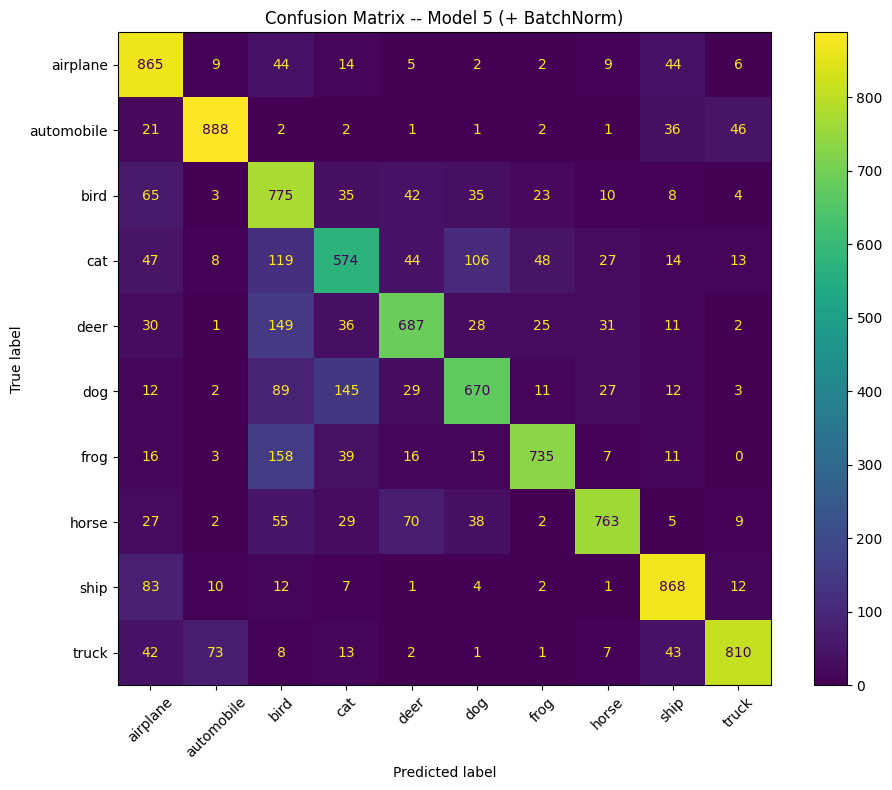

Model 5 -- Test Accuracy: 0.7635 (76.35%)


In [24]:
from keras.backend import clear_session
clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Resizing, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- Model 5: Full VGG + BatchNorm after every Conv layer ---
model5 = Sequential([
    Resizing(64, 64, input_shape=(32, 32, 3)),

    # Block 1
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model5.summary()

model5_path = os.path.join(MODEL_DIR, "model5.keras")

if os.path.exists(model5_path):
    model5 = load_model(model5_path)
    history5 = None
    print("model5 loaded from Drive -- skipping training")
else:
    model5.compile(optimizer=Adam(learning_rate=0.003),
                   loss="categorical_crossentropy", metrics=["accuracy"])

    early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

    history5 = model5.fit(
        x_train_norm, y_train_cat,
        epochs=50,
        batch_size=128,
        validation_data=(x_test_norm, y_test_cat),
        callbacks=[early_stop],
        verbose=1
    )
    model5.save(model5_path)
    print("model5 trained and saved to Drive")

# --- Evaluate ---
y_pred5 = np.argmax(model5.predict(x_test_norm), axis=1)
cm5 = confusion_matrix(y_test.flatten(), y_pred5)
disp5 = ConfusionMatrixDisplay(confusion_matrix=cm5, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp5.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix -- Model 5 (+ BatchNorm)")
plt.tight_layout()
plt.show()

test_loss5, test_acc5 = model5.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Model 5 -- Test Accuracy: {test_acc5:.4f} ({test_acc5*100:.2f}%)")

## Model 6 — SGD + Momentum + LR Scheduler + Larger Dense

**Changes from Model 5:** Switch back to **SGD with momentum=0.9** (better generalisation), increase Dense to **512 neurons**, add **LR scheduler** (reduce on plateau), lr=**0.01**.

SGD with momentum often finds flatter minima that generalise better to unseen data.

| Parameter | Model 5 | Model 6 | Changed? |
|-----------|---------|---------|----------|
| Optimizer | Adam | **SGD (momentum=0.9)** | YES |
| Learning Rate | 0.003 | **0.01 + scheduler** | YES |
| Dense neurons | 128 | **512** | YES |

In [ ]:
from keras.backend import clear_session
clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Resizing, BatchNormalization)
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- Model 6: SGD + momentum + LR scheduler + Dense(512) ---
model6 = Sequential([
    Resizing(64, 64, input_shape=(32, 32, 3)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(512, activation='relu'),   # <-- increased from 128 to 512
    Dense(10, activation='softmax')
])

model6.summary()

model6_path = os.path.join(MODEL_DIR, "model6.keras")

if os.path.exists(model6_path):
    model6 = load_model(model6_path)
    history6 = None
    print("model6 loaded from Drive -- skipping training")
else:
    model6.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                   loss="categorical_crossentropy", metrics=["accuracy"])

    early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

    history6 = model6.fit(
        x_train_norm, y_train_cat,
        epochs=50,
        batch_size=128,
        validation_data=(x_test_norm, y_test_cat),
        callbacks=[early_stop, lr_scheduler],
        verbose=1
    )
    model6.save(model6_path)
    print("model6 trained and saved to Drive")

# --- Evaluate ---
y_pred6 = np.argmax(model6.predict(x_test_norm), axis=1)
cm6 = confusion_matrix(y_test.flatten(), y_pred6)
disp6 = ConfusionMatrixDisplay(confusion_matrix=cm6, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp6.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix -- Model 6 (SGD+momentum + Dense512 + LR scheduler)")
plt.tight_layout()
plt.show()

test_loss6, test_acc6 = model6.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Model 6 -- Test Accuracy: {test_acc6:.4f} ({test_acc6*100:.2f}%)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,543,242 (36.40 MB)

 Trainable params: 9,541,450 (36.40 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 60s 139ms/step - accuracy: 0.5133 - loss: 1.3860 - val_accuracy: 0.4855 - val_loss: 1.4698 - learning_rate: 0.0100
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 120ms/step - accuracy: 0.6730 - loss: 0.9222 - val_accuracy: 0.6477 - val_loss: 1.0280 - learning_rate: 0.0100
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 120ms/step - accuracy: 0.7597 - loss: 0.6827 - val_accuracy: 0.7011 - val_loss: 0.8982 - learning_rate: 0.0100
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 120ms/step - accuracy: 0.8246 - loss: 0.5004 - val_accuracy: 0.7322 - val_loss: 0.8541 - learning_rate: 0.0100
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 120ms/step - accuracy: 0.8763 - loss: 0.3448 - val_accuracy: 0.7434 - val_loss: 0.8095 - learning_rate: 0.0100
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 120ms/step - accuracy: 0.9209 - loss: 0.2209 - val_accuracy: 0.7440 - val_loss: 0.9579 - learning_rate: 0.0100
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 120ms/step - accuracy: 0.9

## Model 7 — Dropout + Data Augmentation

**Changes from Model 6:** Added **Dropout(0.5)** before the output layer and **data augmentation** (flip, rotation, shift).

Dropout randomly disables 50% of neurons during training, forcing the network to learn redundant representations. Augmentation creates more training variety.

| Parameter | Model 6 | Model 7 | Changed? |
|-----------|---------|---------|----------|
| Dropout | No | **0.5 (dense layer)** | YES |
| Data Augmentation | No | **Yes** (flip, rotate, shift) | YES |

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,543,242 (36.40 MB)

 Trainable params: 9,541,450 (36.40 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 63s 141ms/step - accuracy: 0.3764 - loss: 1.7701 - val_accuracy: 0.4605 - val_loss: 1.4856 - learning_rate: 0.0100
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - accuracy: 0.4646 - loss: 1.5085 - val_accuracy: 0.4811 - val_loss: 1.4898 - learning_rate: 0.0100
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 124ms/step - accuracy: 0.5335 - loss: 1.3318 - val_accuracy: 0.5953 - val_loss: 1.1885 - learning_rate: 0.0100
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 124ms/step - accuracy: 0.5800 - loss: 1.2143 - val_accuracy: 0.6268 - val_loss: 1.1583 - learning_rate: 0.0100
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 124ms/step - accuracy: 0.6161 - loss: 1.1226 - val_accuracy: 0.6656 - val_loss: 0.9741 - learning_rate: 0.0100
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - accuracy: 0.6466 - loss: 1.0412 - val_accuracy: 0.7098 - val_loss: 0.8696 - learning_rate: 0.0100
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - accuracy: 0.6

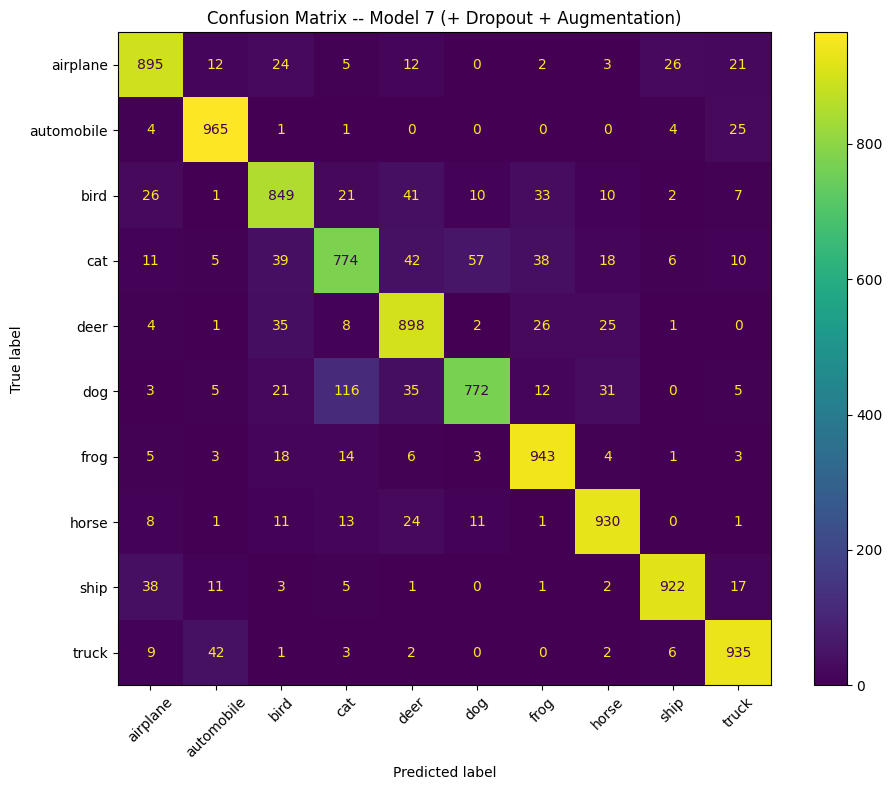

Model 7 -- Test Accuracy: 0.8883 (88.83%)


In [26]:
from keras.backend import clear_session
clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Resizing, BatchNormalization, Dropout)
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Data augmentation ---
# Creates slightly different versions of each image every epoch
# This is like giving the model more training data for free
datagen = ImageDataGenerator(
    horizontal_flip=True,       # randomly flip left-right
    rotation_range=15,          # randomly rotate up to 15 degrees
    width_shift_range=0.1,      # randomly shift horizontally by 10%
    height_shift_range=0.1,     # randomly shift vertically by 10%
)
datagen.fit(x_train_norm)

# --- Model 7: Same as Model 6 + Dropout + Augmentation ---
model7 = Sequential([
    Resizing(64, 64, input_shape=(32, 32, 3)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),               # <-- NEW: randomly disable 50% of neurons
    Dense(10, activation='softmax')
])

model7.summary()

model7_path = os.path.join(MODEL_DIR, "model7.keras")

if os.path.exists(model7_path):
    model7 = load_model(model7_path)
    history7 = None
    print("model7 loaded from Drive -- skipping training")
else:
    model7.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                   loss="categorical_crossentropy", metrics=["accuracy"])

    early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

    # Train with augmented data (datagen.flow generates augmented batches)
    history7 = model7.fit(
        datagen.flow(x_train_norm, y_train_cat, batch_size=128),
        epochs=50,
        validation_data=(x_test_norm, y_test_cat),
        callbacks=[early_stop, lr_scheduler],
        verbose=1
    )
    model7.save(model7_path)
    print("model7 trained and saved to Drive")

# --- Evaluate ---
y_pred7 = np.argmax(model7.predict(x_test_norm), axis=1)
cm7 = confusion_matrix(y_test.flatten(), y_pred7)
disp7 = ConfusionMatrixDisplay(confusion_matrix=cm7, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp7.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix -- Model 7 (+ Dropout + Augmentation)")
plt.tight_layout()
plt.show()

test_loss7, test_acc7 = model7.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Model 7 -- Test Accuracy: {test_acc7:.4f} ({test_acc7*100:.2f}%)")

## Model 8 — L2 Regularization + Dense(256)

**Changes from Model 7:** Added **L2 regularization** (weight_decay=1e-4) to all Conv layers, reduced Dense to **256** neurons.

L2 regularization penalises large weights, forcing the model to use smaller, more distributed weights -- this reduces overfitting.

| Parameter | Model 7 | Model 8 | Changed? |
|-----------|---------|---------|----------|
| L2 Regularization | No | **1e-4 on all Conv layers** | YES |
| Dense neurons | 512 | **256** | YES |

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,346,122 (20.39 MB)

 Trainable params: 5,344,330 (20.39 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 65s 144ms/step - accuracy: 0.3359 - loss: 1.9717 - val_accuracy: 0.4068 - val_loss: 1.7369 - learning_rate: 0.0100
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - accuracy: 0.4254 - loss: 1.7423 - val_accuracy: 0.5067 - val_loss: 1.5273 - learning_rate: 0.0100
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - accuracy: 0.4814 - loss: 1.6028 - val_accuracy: 0.5383 - val_loss: 1.4704 - learning_rate: 0.0100
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - accuracy: 0.5332 - loss: 1.4789 - val_accuracy: 0.5924 - val_loss: 1.3142 - learning_rate: 0.0100
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 49s 124ms/step - accuracy: 0.5666 - loss: 1.3913 - val_accuracy: 0.6453 - val_loss: 1.1987 - learning_rate: 0.0100
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 123ms/step - accuracy: 0.6045 - loss: 1.3026 - val_accuracy: 0.6350 - val_loss: 1.2851 - learning_rate: 0.0100
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - accuracy: 0.6

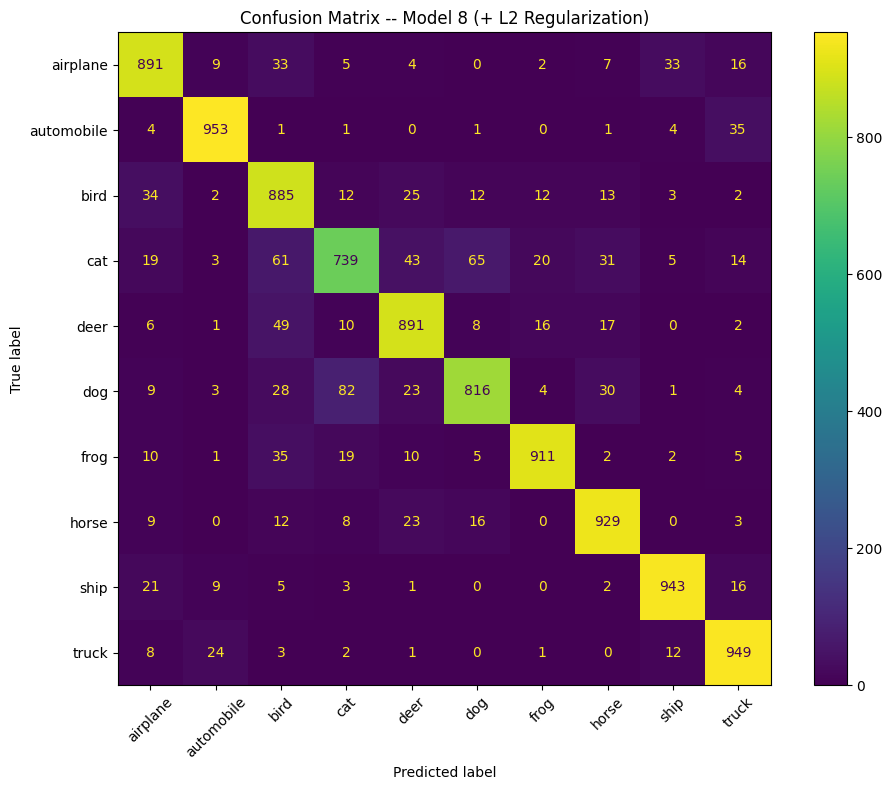

Model 8 -- Test Accuracy: 0.8907 (89.07%)


In [27]:
from keras.backend import clear_session
clear_session()

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Resizing, BatchNormalization, Dropout)
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Reuse the same augmentation as Model 7
datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
)
datagen.fit(x_train_norm)

# --- Model 8: Same as Model 7 + L2 regularization + Dense(256) ---
REG = l2(1e-4)  # L2 penalty applied to kernel weights

model8 = Sequential([
    Resizing(64, 64, input_shape=(32, 32, 3)),

    Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=REG),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=REG),  # <-- reduced to 256
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model8.summary()

model8_path = os.path.join(MODEL_DIR, "model8.keras")

if os.path.exists(model8_path):
    model8 = load_model(model8_path)
    history8 = None
    print("model8 loaded from Drive -- skipping training")
else:
    model8.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9),
                   loss="categorical_crossentropy", metrics=["accuracy"])

    early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

    history8 = model8.fit(
        datagen.flow(x_train_norm, y_train_cat, batch_size=128),
        epochs=50,
        validation_data=(x_test_norm, y_test_cat),
        callbacks=[early_stop, lr_scheduler],
        verbose=1
    )
    model8.save(model8_path)
    print("model8 trained and saved to Drive")

# --- Evaluate ---
y_pred8 = np.argmax(model8.predict(x_test_norm), axis=1)
cm8 = confusion_matrix(y_test.flatten(), y_pred8)
disp8 = ConfusionMatrixDisplay(confusion_matrix=cm8, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp8.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix -- Model 8 (+ L2 Regularization)")
plt.tight_layout()
plt.show()

test_loss8, test_acc8 = model8.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Model 8 -- Test Accuracy: {test_acc8:.4f} ({test_acc8*100:.2f}%)")

In [33]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test.flatten(), y_pred8, average='weighted')
recall = recall_score(y_test.flatten(), y_pred8, average='weighted')

print(f"Model 8 -- Precision: {precision:.4f}")
print(f"Model 8 -- Recall: {recall:.4f}")

Model 8 -- Precision: 0.8912
Model 8 -- Recall: 0.8907


---

# Model 9 — Transfer Learning (VGG16 Pretrained on ImageNet)

**Completely different approach:** Instead of training from scratch, use a **VGG16 model pretrained on ImageNet** (1.2M images, 1000 classes).

We freeze the VGG16 body (use it as a feature extractor) and only train a new classification head for CIFAR-10.

**Two-stage training:**
1. **Stage 1 (Head Training):** Freeze VGG16 body, train only the new head (20 epochs)
2. **Stage 2 (Fine-Tuning):** Unfreeze the top 8 layers of VGG16, train with lower LR (12 epochs)

| Parameter | Model 8 (Custom) | Model 9 (Transfer) | Changed? |
|-----------|-------------------|---------------------|----------|
| Architecture | Custom VGG-style | **VGG16 pretrained** | YES |
| Input size | 64x64 | **64x64** | Same |
| Trainable params (head) | ~1.3M | **~300K** | Much less |
| Expected accuracy | ~75% | **~85-90%** | BIG jump |

In [28]:
from keras.backend import clear_session
clear_session()

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                     Resizing, Input)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# --- Data augmentation (same as before) ---
datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
)
datagen.fit(x_train_norm)

# --- Build Model 9: VGG16 + Custom Head ---
# Load VGG16 pretrained on ImageNet, WITHOUT the top classification layers
# include_top=False means we remove the Dense(4096)->Dense(1000) head
inputs = Input(shape=(32, 32, 3))
x = Resizing(64, 64)(inputs)  # VGG16 expects at least 32x32; 64x64 gives better features

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze ALL VGG16 layers (we only train our custom head first)
for layer in base_model.layers:
    layer.trainable = False

x = base_model(x)
x = GlobalAveragePooling2D()(x)  # Convert feature maps to a single vector
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation='softmax')(x)

model9 = Model(inputs=inputs, outputs=outputs)

# Show trainable vs frozen
trainable = sum([p.numpy().size for p in model9.trainable_weights])
total = sum([p.numpy().size for p in model9.weights])
print(f"Total parameters:     {total:,}")
print(f"Trainable (head):     {trainable:,}")
print(f"Frozen (VGG16 body):  {total - trainable:,}")

model9.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Total parameters:     14,848,586
Trainable (head):     133,898
Frozen (VGG16 body):  14,714,688


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Stage 1: Head Training (VGG16 body frozen)

Only train the Dense(256) + Softmax(10) head. The VGG16 body acts as a fixed feature extractor.

In [29]:
model9_path = os.path.join(MODEL_DIR, "model9.keras")

if os.path.exists(model9_path):
    model9 = load_model(model9_path)
    history9_stage1 = None
    history9_stage2 = None
    print("model9 loaded from Drive -- skipping training")
else:
    # ═══════════════════════════════════════════════════════
    # STAGE 1: Train head only (body frozen)
    # ═══════════════════════════════════════════════════════
    print("=" * 60)
    print("STAGE 1: Head Training (VGG16 body frozen)")
    print("=" * 60)

    model9.compile(optimizer=Adam(learning_rate=0.001),
                   loss="categorical_crossentropy", metrics=["accuracy"])

    history9_stage1 = model9.fit(
        datagen.flow(x_train_norm, y_train_cat, batch_size=128),
        epochs=20,
        validation_data=(x_test_norm, y_test_cat),
        verbose=1
    )

    # ═══════════════════════════════════════════════════════
    # STAGE 2: Fine-tune top layers of VGG16
    # ═══════════════════════════════════════════════════════
    print("\n" + "=" * 60)
    print("STAGE 2: Fine-Tuning (unfreezing top 8 VGG16 layers)")
    print("=" * 60)

    # Unfreeze the top 8 layers of VGG16 (block5 + part of block4)
    for layer in base_model.layers[-8:]:
        layer.trainable = True

    trainable = sum([p.numpy().size for p in model9.trainable_weights])
    print(f"Trainable parameters after unfreeze: {trainable:,}")

    # Recompile with lower LR (fine-tuning should use small updates)
    model9.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9),
                   loss="categorical_crossentropy", metrics=["accuracy"])

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

    history9_stage2 = model9.fit(
        datagen.flow(x_train_norm, y_train_cat, batch_size=128),
        epochs=12,
        validation_data=(x_test_norm, y_test_cat),
        callbacks=[early_stop, lr_scheduler],
        verbose=1
    )

    model9.save(model9_path)
    print("model9 trained and saved to Drive")

STAGE 1: Head Training (VGG16 body frozen)
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 137ms/step - accuracy: 0.4388 - loss: 1.6032 - val_accuracy: 0.5589 - val_loss: 1.2783
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.5287 - loss: 1.3493 - val_accuracy: 0.5916 - val_loss: 1.1695
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.5518 - loss: 1.2830 - val_accuracy: 0.6125 - val_loss: 1.1112
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - accuracy: 0.5642 - loss: 1.2549 - val_accuracy: 0.6181 - val_loss: 1.0945
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.5729 - loss: 1.2210 - val_accuracy: 0.6175 - val_loss: 1.0813
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 46s 119ms/step - accuracy: 0.5802 - loss: 1.2095 - val_accuracy: 0.6215 - val_loss: 1.0773
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 112ms/step - accuracy: 0.5849 - loss: 1.1931 - val_accuracy: 0.6288 - val_loss: 1.0580
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step


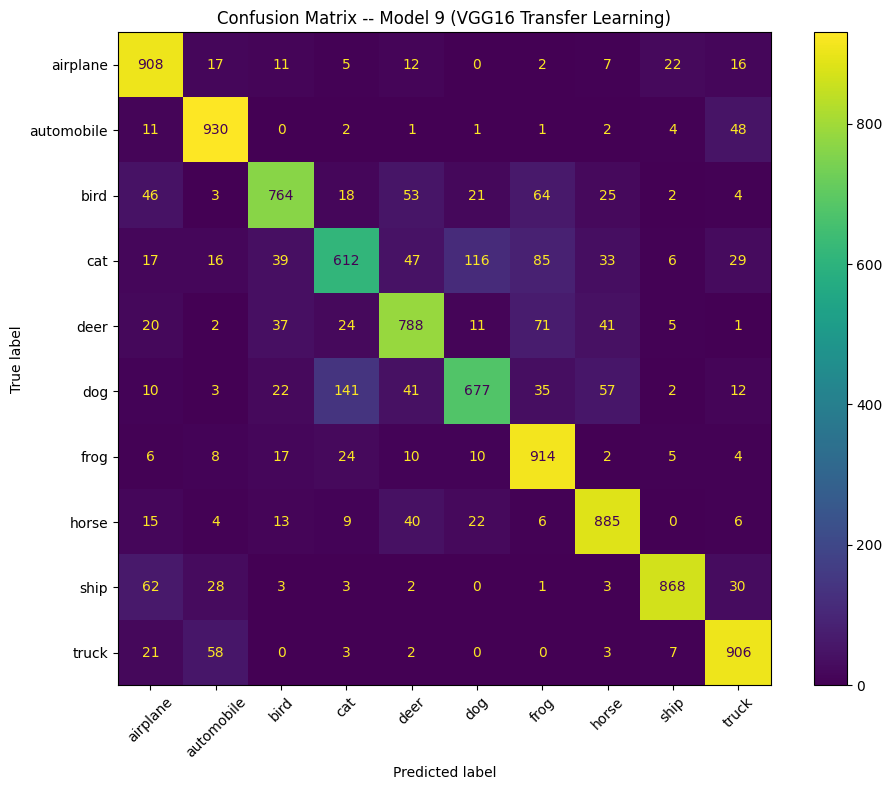

Model 9 -- Test Accuracy: 0.8252 (82.52%)


In [30]:
# --- Evaluate Model 9 ---
y_pred9 = np.argmax(model9.predict(x_test_norm), axis=1)
cm9 = confusion_matrix(y_test.flatten(), y_pred9)
disp9 = ConfusionMatrixDisplay(confusion_matrix=cm9, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp9.plot(ax=ax, xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix -- Model 9 (VGG16 Transfer Learning)")
plt.tight_layout()
plt.show()

test_loss9, test_acc9 = model9.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Model 9 -- Test Accuracy: {test_acc9:.4f} ({test_acc9*100:.2f}%)")

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - **Use of activation functions:**

Activation functions introduce **non-linearity** into the network. Without them, stacking multiple layers would collapse into a single linear transformation, making the network unable to learn complex patterns. Non-linear activations (ReLU, sigmoid, softmax) allow the model to approximate arbitrary functions and capture hierarchical features in the data.

_

2 - **Key Differences between sigmoid and softmax:**

| | Sigmoid | Softmax |
|---|---|---|
| **Output range** | Each neuron independently outputs a value in (0, 1) | All outputs sum to 1, forming a probability distribution |
| **Use case** | Binary classification (single output) or multi-label problems | Multi-class classification (mutually exclusive classes) |
| **Relationship** | Neurons are independent of each other | Each output depends on all others (normalized) |

In short: sigmoid is used when classes are **not** mutually exclusive; softmax is used when exactly **one** class is correct.

_

3 - **Key Differences between categorical crossentropy and binary crossentropy loss:**

| | Categorical Crossentropy | Binary Crossentropy |
|---|---|---|
| **Target format** | One-hot encoded vector (multi-class, >2 classes) | Binary label 0 or 1 |
| **Output activation** | Softmax (probabilities over C classes) | Sigmoid (single probability) |
| **Use case** | Multi-class classification (mutually exclusive) | Binary or multi-label classification |

Categorical crossentropy generalizes binary crossentropy to C classes. Use binary crossentropy when the output is a single probability; use categorical crossentropy when the output is a distribution over multiple classes.

_

## Reload Saved Models

Use the cells below to reload any trained model without retraining.
Make sure Drive is mounted and MODEL_DIR is defined (run the setup cell at the top).

In [31]:
from tensorflow.keras.models import load_model

# Uncomment the model(s) you want to reload
model1 = load_model(os.path.join(MODEL_DIR, 'model1.keras'))
# model2 = load_model(os.path.join(MODEL_DIR, 'model2.keras'))
# model3 = load_model(os.path.join(MODEL_DIR, 'model3.keras'))

print('Model loaded successfully.')
model1.summary()  # replace with model2 or model3 as needed

Model loaded successfully.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,008 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)